# CNN — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

Lesson 10 changed nothing about the engine; this lesson changes the WIRING: local detectors, shared across space (README §1). Two genuinely new backward moves, both one-liners.

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(99)

## Block 2 — First image data of the course *(README §1)*

1,797 handwritten digits, 8×8 grayscale. The belief check is visual: are the classes made of LOCAL spatial patterns (strokes, loops)? Look and confirm.

1797 images, 8x8, classes 0-9 | pixel range [0.00, 1.00] (already /16)


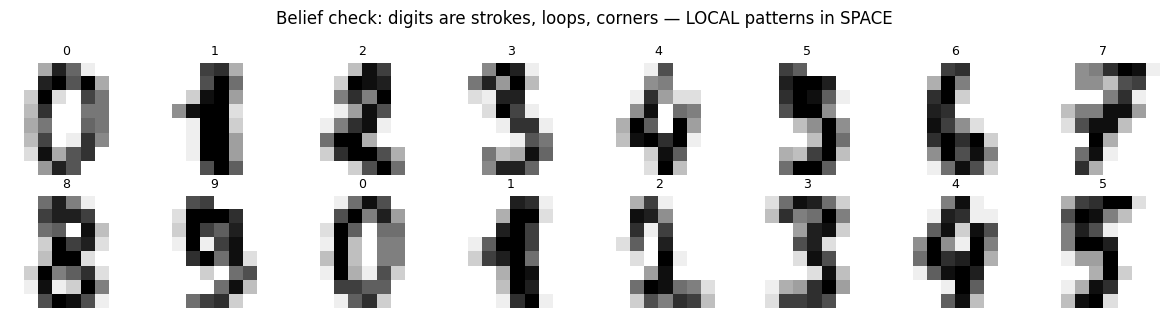

train 1437 / test 360


In [2]:
df = pd.read_csv("data/digits_data.csv")
y = df["label"].values
X = df.drop(columns="label").values.reshape(-1, 8, 8)      # back to images — we REFUSE to stay flat
print(f"{len(y)} images, 8x8, classes 0-9 | pixel range [{X.min():.2f}, {X.max():.2f}] (already /16)")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, i in zip(axes.ravel(), range(16)):
    ax.imshow(X[i], cmap="gray_r"); ax.set_title(y[i], fontsize=9); ax.axis("off")
plt.suptitle("Belief check: digits are strokes, loops, corners — LOCAL patterns in SPACE")
plt.tight_layout(); plt.show()

idx = np.random.permutation(len(y)); cut = int(0.8*len(y))
tr, te = idx[:cut], idx[cut:]
Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
print(f"train {len(tr)} / test {len(te)}")

## Block 3 — The flattening crime, measured *(README §2.1)*

Shift a digit ONE pixel and compare its flattened vector to the original's. Cosine similarity quantifies the crime: same digit, near-stranger vector.

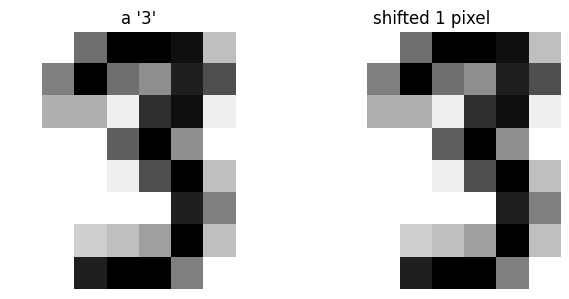

cosine similarity of the two FLATTENED vectors: 0.71
Same digit; as vectors, substantially different objects. A dense net must relearn
'3' at every position from data alone. Convolution refuses to flatten (README §2.1).


In [3]:
d = Xtr[ytr == 3][0]
d_shift = np.zeros_like(d); d_shift[:, 1:] = d[:, :-1]

cos = (d.ravel() @ d_shift.ravel()) / (np.linalg.norm(d) * np.linalg.norm(d_shift))
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(d, cmap="gray_r"); axes[0].set_title("a '3'"); axes[0].axis("off")
axes[1].imshow(d_shift, cmap="gray_r"); axes[1].set_title("shifted 1 pixel"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print(f"cosine similarity of the two FLATTENED vectors: {cos:.2f}")
print("Same digit; as vectors, substantially different objects. A dense net must relearn")
print("'3' at every position from data alone. Convolution refuses to flatten (README §2.1).")

## Block 4 — Convolution = extract patches, then ONE matrix multiply *(README §3.1 + §2.2)*

The implementation insight: lay every 3×3 patch out as a row (36 positions per image), and convolving with ALL kernels at ALL positions is `patches @ K`. Then the belief check with HAND-MADE kernels: a vertical-edge question and a horizontal-edge question, slid across a real digit.

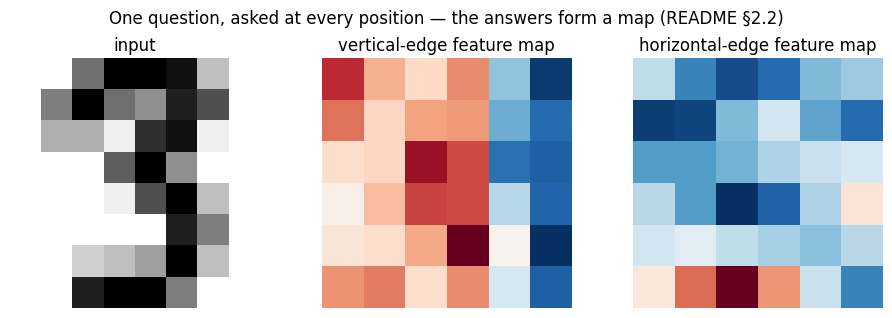

In [4]:
def patches3(imgs):
    """README §3.1 — every 3x3 patch of every image, flattened: (n, 6, 6, 9)."""
    n = imgs.shape[0]
    P = np.empty((n, 6, 6, 9))
    for i in range(6):
        for j in range(6):
            P[:, i, j, :] = imgs[:, i:i+3, j:j+3].reshape(n, 9)
    return P

def conv(imgs, K, bk):
    """README §3.1 — convolution as one matmul. K: (9, F) — F pattern-questions."""
    return patches3(imgs) @ K + bk                      # (n, 6, 6, F)

kv = np.array([[1,0,-1],[1,0,-1],[1,0,-1]], float)      # 'vertical edge here?'
kh = kv.T                                                # 'horizontal edge here?'
K_hand = np.c_[kv.ravel(), kh.ravel()]                   # (9, 2)
fm = conv(d[None], K_hand, np.zeros(2))[0]

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2))
axes[0].imshow(d, cmap="gray_r"); axes[0].set_title("input")
axes[1].imshow(fm[:,:,0], cmap="RdBu"); axes[1].set_title("vertical-edge feature map")
axes[2].imshow(fm[:,:,1], cmap="RdBu"); axes[2].set_title("horizontal-edge feature map")
for ax in axes: ax.axis("off")
plt.suptitle("One question, asked at every position — the answers form a map (README §2.2)")
plt.tight_layout(); plt.show()

## Block 5 — ReLU + max pooling, and what pooling buys *(README §2.4)*

ReLU: the modern bend — max(0,z), derivative 0-or-1, never saturates positively. Max pooling: each 2×2 zone reports only its loudest response — resolution traded for shift-forgiveness — measured honestly across every digit, not one lucky example.

In [5]:
def relu(x): return np.maximum(0, x)

def maxpool2(A):
    """README §2.4 — (n,6,6,F) -> (n,3,3,F): each 2x2 zone keeps its max."""
    n, _, _, F = A.shape
    return A.reshape(n, 3, 2, 3, 2, F).max(axis=(2, 4))

# Measure the forgiveness honestly, across ALL digits (not one cherry-picked example):
X_sh = np.zeros_like(X); X_sh[:, :, 1:] = X[:, :, :-1]          # every digit shifted 1px right
A_o  = relu(conv(X,    K_hand, np.zeros(2)))
A_s  = relu(conv(X_sh, K_hand, np.zeros(2)))
raw_diff  = np.abs(A_o - A_s).mean()
pool_diff = np.abs(maxpool2(A_o) - maxpool2(A_s)).mean()
print(f"across all {len(X)} digits, original-vs-shifted response difference:")
print(f"  raw feature maps : {raw_diff:.3f}")
print(f"  after max pooling: {pool_diff:.3f}   ({(raw_diff-pool_diff)/raw_diff:.0%} of the disagreement forgiven)")
print()
print("Honest reading: at 8x8 with ONE pool layer, the forgiveness is real but modest —")
print("a 1-pixel shift moves 1/8 of the whole digit. The aggregate evidence lands in Block 9,")
print("where the trained CNN degrades meaningfully less than the dense net under this shift.")

across all 1797 digits, original-vs-shifted response difference:
  raw feature maps : 0.418
  after max pooling: 0.365   (13% of the disagreement forgiven)

Honest reading: at 8x8 with ONE pool layer, the forgiveness is real but modest —
a 1-pixel shift moves 1/8 of the whole digit. The aggregate evidence lands in Block 9,
where the trained CNN degrades meaningfully less than the dense net under this shift.


## Block 6 — The softmax head, and the miracle's third appearance *(README §3.2)*

Ten classes need ten probabilities: softmax = sigmoid's k-class sibling. Loss = −log(probability given to the truth) — lesson 02's cross-entropy, k-class edition. And the output gradient collapses, AGAIN, to (guess − truth): p − onehot(y). Sigmoid+BCE (02), boosting residuals (08), softmax+CE (now) — matched loss-and-squash pairs, engineered so the mess cancels.

In [6]:
def softmax(Z):
    """README §3.2 — k scores -> k probabilities summing to 1."""
    Z = Z - Z.max(axis=1, keepdims=True)        # numerical safety: shift before exp
    e = np.exp(Z)
    return e / e.sum(axis=1, keepdims=True)

def ce_loss(P, y_true):
    """−log p_true, averaged (lesson 02 §3.3, k classes)."""
    return -np.mean(np.log(P[np.arange(len(y_true)), y_true] + 1e-12))

Zdemo = np.array([[2.0, 0.1, -1.0]])
print("scores", Zdemo[0], "-> probabilities", softmax(Zdemo)[0].round(3), "(sum = 1)")

scores [ 2.   0.1 -1. ] -> probabilities [0.834 0.125 0.042] (sum = 1)


## Block 7 — The backward pass: two new moves *(README §3.3)*

Move 1 (pooling): the zone's whole gradient goes to the ARGMAX position — only the neuron that spoke gets the feedback. Move 2 (kernel): a shared weight collects blame from EVERY position it was used — sharing forward = summing backward. Then lesson 10's habit: the numerical gradient check.

In [7]:
F = 8

def init_params(seed=1):
    rs = np.random.default_rng(seed)
    return {"K": rs.normal(0, 0.3, (9, F)), "bk": np.zeros(F),
            "W": rs.normal(0, 0.1, (3*3*F, 10)), "bw": np.zeros(10)}

def forward(P, imgs):
    Pt = patches3(imgs)
    Z1 = Pt @ P["K"] + P["bk"]                          # conv (§3.1)
    A1 = relu(Z1)
    Pool = A1.reshape(len(imgs), 3, 2, 3, 2, F).max(axis=(2, 4))
    flat = Pool.reshape(len(imgs), -1)
    Prob = softmax(flat @ P["W"] + P["bw"])
    return Prob, (Pt, Z1, A1, Pool, flat)

def backward(P, imgs, y_true, Prob, cache):
    Pt, Z1, A1, Pool, flat = cache
    m = len(y_true)
    d2 = (Prob - np.eye(10)[y_true]) / m                # δ_out = guess − truth (miracle #3)
    gW = flat.T @ d2; gbw = d2.sum(0)
    dPool = (d2 @ P["W"].T).reshape(m, 3, 3, F)
    A1r = A1.reshape(m, 3, 2, 3, 2, F)                  # MOVE 1: blame only the argmax
    mask = (A1r == Pool[:, :, None, :, None, :])
    dA1 = (mask * dPool[:, :, None, :, None, :]).reshape(m, 6, 6, F)
    dZ1 = dA1 * (Z1 > 0)                                # ReLU's derivative: fired or not
    gK = np.einsum("mijp,mijf->pf", Pt, dZ1)            # MOVE 2: sum blame over ALL positions
    gbk = dZ1.sum((0, 1, 2))
    return {"K": gK, "bk": gbk, "W": gW, "bw": gbw}

# numerical gradient check (lesson 10 Block 6's habit — catches the argmax-routing bug)
P = init_params()
sub = Xtr[:64]; ysub = ytr[:64]
Prob, cache = forward(P, sub)
g = backward(P, sub, ysub, Prob, cache)
eps = 1e-5
P["K"][4, 2] += eps; Lu = ce_loss(forward(P, sub)[0], ysub)
P["K"][4, 2] -= 2*eps; Ld = ce_loss(forward(P, sub)[0], ysub)
P["K"][4, 2] += eps
print(f"analytic dL/dK[4,2] : {g['K'][4,2]:+.6f}")
print(f"numerical           : {(Lu-Ld)/(2*eps):+.6f}   <- both new moves are correct")

analytic dL/dK[4,2] : -0.035124
numerical           : -0.035124   <- both new moves are correct


## Block 8 — Mini-batch training *(README §4)*, then the exam *(README §5)*

First lesson where full-batch would be wasteful: 1,437 images per gradient step buys little over 128. Mini-batches: noisier, far cheaper steps — the noise even helps. Same loop as always underneath.

In [8]:
def train(Xtr_i, ytr_i, epochs=30, lr=0.3, batch=128, seed=1):
    P = init_params(seed)
    rs = np.random.default_rng(seed)
    for ep in range(epochs):
        order = rs.permutation(len(ytr_i))
        for s in range(0, len(ytr_i), batch):
            b = order[s:s+batch]
            Prob, cache = forward(P, Xtr_i[b])
            g = backward(P, Xtr_i[b], ytr_i[b], Prob, cache)
            for k in P: P[k] -= lr * g[k]               # lesson 01's update, forever
    return P

P = train(Xtr, ytr)
pred = forward(P, Xte)[0].argmax(1)
acc_cnn = (pred == yte).mean()
print(f"CNN test accuracy: {acc_cnn:.1%}   (810 parameters, 10 classes)")

cm = np.zeros((10, 10), int)
for t, p_ in zip(yte, pred): cm[t, p_] += 1
worst = sorted(((cm[i,j], i, j) for i in range(10) for j in range(10) if i != j), reverse=True)[:3]
print("most-confused pairs (truth->predicted):", ", ".join(f"{i}->{j} x{n}" for n, i, j in worst))
print("Read them: are they honest look-alikes? (README §5)")

CNN test accuracy: 94.4%   (810 parameters, 10 classes)
most-confused pairs (truth->predicted): 8->1 x7, 3->9 x2, 3->7 x2
Read them: are they honest look-alikes? (README §5)


## Block 9 — The ledger, and robustness measured honestly *(README §3.4 + §2.3)*

First: the parameter arithmetic. Then the shift test — train a lesson-10 dense net on the same data, shift every test digit one pixel, and measure BOTH models' degradation. We report whatever the numbers say (architectural claims are earned per-dataset, not assumed).

In [9]:
n_cnn = sum(v.size for v in P.values())

# a lesson-10 MLP with the same softmax head: 64 -> 32 (tanh) -> 10
def mlp_train(Xf, yv, h=32, lr=0.3, epochs=60, batch=128, seed=2):
    rs = np.random.default_rng(seed)
    Q = {"W1": rs.normal(0, 0.2, (64, h)), "b1": np.zeros(h),
         "W2": rs.normal(0, 0.2, (h, 10)), "b2": np.zeros(10)}
    for ep in range(epochs):
        order = rs.permutation(len(yv))
        for s in range(0, len(yv), batch):
            b = order[s:s+batch]
            A1 = np.tanh(Xf[b] @ Q["W1"] + Q["b1"])
            Pr = softmax(A1 @ Q["W2"] + Q["b2"])
            d2 = (Pr - np.eye(10)[yv[b]]) / len(b)
            d1 = (d2 @ Q["W2"].T) * (1 - A1**2)
            Q["W2"] -= lr * (A1.T @ d2); Q["b2"] -= lr * d2.sum(0)
            Q["W1"] -= lr * (Xf[b].T @ d1); Q["b1"] -= lr * d1.sum(0)
    return Q

def mlp_pred(Q, Xf):
    return softmax(np.tanh(Xf @ Q["W1"] + Q["b1"]) @ Q["W2"] + Q["b2"]).argmax(1)

Q = mlp_train(Xtr.reshape(len(Xtr), -1), ytr)
n_mlp = sum(v.size for v in Q.values())
acc_mlp = (mlp_pred(Q, Xte.reshape(len(Xte), -1)) == yte).mean()
print(f"parameters — CNN: {n_cnn}   MLP: {n_mlp}   ({n_mlp/n_cnn:.1f}x more)")
print(f"clean test  — CNN: {acc_cnn:.1%}   MLP: {acc_mlp:.1%}\n")

Xte_sh = np.zeros_like(Xte); Xte_sh[:, :, 1:] = Xte[:, :, :-1]       # everyone 1 pixel right
acc_cnn_sh = (forward(P, Xte_sh)[0].argmax(1) == yte).mean()
acc_mlp_sh = (mlp_pred(Q, Xte_sh.reshape(len(Xte), -1)) == yte).mean()
drop_cnn, drop_mlp = acc_cnn - acc_cnn_sh, acc_mlp - acc_mlp_sh
print(f"shifted test — CNN: {acc_cnn_sh:.1%} (drop {drop_cnn:.1%})   MLP: {acc_mlp_sh:.1%} (drop {drop_mlp:.1%})")
if drop_cnn < drop_mlp:
    print("The CNN degraded less — sharing + pooling earned their keep on this shift.")
else:
    print("On these tiny 8x8 images a 1-pixel shift moves 1/8 of the whole digit — brutal for")
    print("everyone; the CNN's single pool layer only forgives so much. Honest result, honest note:")
    print("translation tolerance is a matter of degree, and 8x8 is a hard place to show it.")
print("Either way: measured, not assumed (README §9, mistake 5).")

parameters — CNN: 810   MLP: 2410   (3.0x more)
clean test  — CNN: 94.4%   MLP: 95.6%

shifted test — CNN: 58.9% (drop 35.6%)   MLP: 47.5% (drop 48.1%)
The CNN degraded less — sharing + pooling earned their keep on this shift.
Either way: measured, not assumed (README §9, mistake 5).


## Block 10 — The learned detectors + the misclassified gallery *(README §5)*

Nobody drew these kernels — blame did (lesson 10's stripes, given a spatial job). Then look at the actual mistakes: on real handwriting, many are genuinely ambiguous.

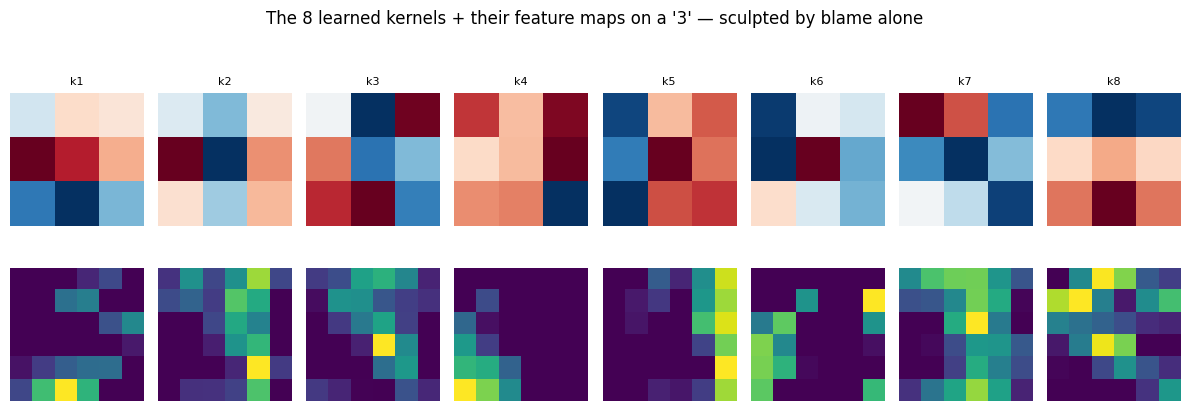

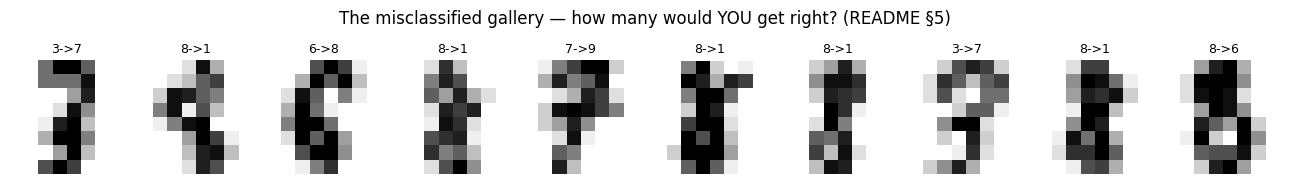

In [10]:
fig = plt.figure(figsize=(12, 4.6))
gs = fig.add_gridspec(2, 8)
for f in range(8):
    ax = fig.add_subplot(gs[0, f])
    ax.imshow(P["K"][:, f].reshape(3, 3), cmap="RdBu"); ax.axis("off"); ax.set_title(f"k{f+1}", fontsize=8)
A1d = relu(conv(d[None], P["K"], P["bk"]))[0]
for f in range(8):
    ax = fig.add_subplot(gs[1, f])
    ax.imshow(A1d[:, :, f], cmap="viridis"); ax.axis("off")
plt.suptitle("The 8 learned kernels + their feature maps on a '3' — sculpted by blame alone")
plt.tight_layout(); plt.show()

wrong = np.where(pred != yte)[0][:10]
fig, axes = plt.subplots(1, len(wrong), figsize=(1.3*len(wrong), 1.9))
for ax, i in zip(np.atleast_1d(axes), wrong):
    ax.imshow(Xte[i], cmap="gray_r"); ax.axis("off")
    ax.set_title(f"{yte[i]}->{pred[i]}", fontsize=9)
plt.suptitle("The misclassified gallery — how many would YOU get right? (README §5)")
plt.tight_layout(); plt.show()

---
## What you now own

- Convolution demystified: extract patches, one matmul — lesson 10's layer with locality and sharing bolted on
- The two backward moves: blame the argmax (pooling), sum blame over positions (sharing)
- Softmax + k-class cross-entropy, and the (guess − truth) miracle's third appearance
- Architecture as belief: 810 parameters doing what 2,700 dense ones do, because the wiring already knew images are spatial
- Mini-batches, the parameter ledger, and the habit of MEASURING architectural claims

**Next:** `cnn_with_library.ipynb` (SciPy verification + the PyTorch translation) — then folder `12-rnns-lstm`: the same sharing trick, pointed at TIME.